# TensorFlow and Keras

In [ ]:
#Uncomment and use it
#!pip install tensorflow

In [2]:
import tensorflow as tf
%matplotlib inline  

## Tensors

#### Constants

tf.constant creates constant values, these values do not change
or update during optimization process(training phase)

In [2]:
a = tf.constant([50,10])
print(a)

tf.Tensor([50 10], shape=(2,), dtype=int32)


Few things that we can do with the tensors at the runtime:
1. Directly get a numpy value of the tensor
2. dtype : data type of the tensor(int16/int32/float32/float64)
3. shape: shape of the tensor

In [3]:
print('a in tensorflow ==>', a)
print('numpy value of a ==>', a.numpy())
print('dtype of a ==>', a.dtype)
print('shape of a ==>', a.shape)

a in tensorflow ==> tf.Tensor([50 10], shape=(2,), dtype=int32)
numpy value of a ==> [50 10]
dtype of a ==> <dtype: 'int32'>
shape of a ==> (2,)


We can use inbuild tf.XX() function to create constant tensors, just like numpy.

In [4]:
print('Tensor of Ones: \n',tf.ones(shape=(2, 2)))
print('Tensor of Zeros: \n',tf.zeros(shape=(2, 2)))
print('Random normal values \n', tf.random.normal(shape=(3, 2),
                                                  mean=5, 
                                                  stddev=1))

Tensor of Ones: 
 tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
Tensor of Zeros: 
 tf.Tensor(
[[0. 0.]
 [0. 0.]], shape=(2, 2), dtype=float32)
Random normal values 
 tf.Tensor(
[[4.871285  4.8906217]
 [5.7764964 5.0360312]
 [4.5578136 3.1466203]], shape=(3, 2), dtype=float32)


### Variables

We generally create a variable with some values, call it initialized values, 
convert this constant tensor into a variable and then mutate the variable by using special functions.

In [5]:
x = tf.Variable(5) # Simple variable
print(x)

<tf.Variable 'Variable:0' shape=() dtype=int32, numpy=5>


In [6]:
#randomly initialized variable, like we need for our weights
w = tf.Variable(tf.random.normal(shape=(2, 2))) 
print(w)

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[ 1.2089705 , -0.14459036],
       [-0.64359283, -1.1159893 ]], dtype=float32)>


In [7]:
m = tf.Variable(5) # Simple variable
print(m)

m = tf.Variable(5) 
print('New value', m.assign(2))

m = tf.Variable(5) 
print('increment by 1', m.assign_add(1))

m = tf.Variable(5) 
print('Decrement by 2', m.assign_sub(2))


<tf.Variable 'Variable:0' shape=() dtype=int32, numpy=5>
New value <tf.Variable 'UnreadVariable' shape=() dtype=int32, numpy=2>
increment by 1 <tf.Variable 'UnreadVariable' shape=() dtype=int32, numpy=6>
Decrement by 2 <tf.Variable 'UnreadVariable' shape=() dtype=int32, numpy=3>


### Regression Model building in TensorFlow

#This step is for data creation, x and y

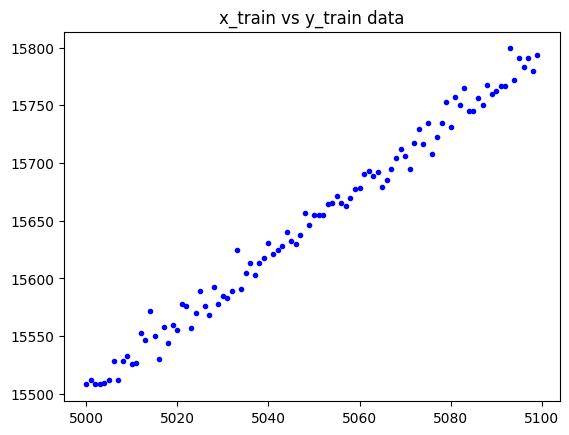

In [8]:
#This step is for data creation, x and y
import numpy as np
x_train= np.array(range(5000,5100)).reshape(-1,1)


y_train=[3*i+np.random.normal(500, 10) for i in x_train]

import matplotlib.pyplot as plt
plt.title("x_train vs y_train data")
plt.plot(x_train, y_train, 'b.')
plt.show()

In [9]:
#Model y=X*W + b
#Model function
def output(x):
    return W*x + b

#Loss function Reduce mean square
def loss_function(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred - y_true))

#Initialize Weights
W = tf.Variable(tf.random.uniform(shape=(1, 1)))
b = tf.Variable(tf.ones(shape=(1,)))

#Optimization
## Writing training/learing loop with GradienTape
learning_rate = 0.000000001
steps = 200 #epochs

for i in range(steps):
    with tf.GradientTape() as tape:
        predictions = output(x_train)
        loss = loss_function(predictions,y_train)
        dloss_dw, dloss_db = tape.gradient(loss, [W, b])
    W.assign_sub(learning_rate * dloss_dw)
    b.assign_sub(learning_rate * dloss_db)
    print(f"epoch : {i}, loss  {loss.numpy()},  W : {W.numpy()}, b  {b.numpy()}")

epoch : 0, loss  161736496.0,  W : [[0.70871645]], b  [1.0000254]
epoch : 1, loss  145661136.0,  W : [[0.83060336]], b  [1.0000495]
epoch : 2, loss  131183536.0,  W : [[0.94627446]], b  [1.0000724]
epoch : 3, loss  118144880.0,  W : [[1.0560467]], b  [1.000094]
epoch : 4, loss  106402168.0,  W : [[1.160221]], b  [1.0001147]
epoch : 5, loss  95826616.0,  W : [[1.2590827]], b  [1.0001342]
epoch : 6, loss  86302176.0,  W : [[1.3529028]], b  [1.0001528]
epoch : 7, loss  77724408.0,  W : [[1.4419384]], b  [1.0001705]
epoch : 8, loss  69999200.0,  W : [[1.5264335]], b  [1.0001872]
epoch : 9, loss  63041824.0,  W : [[1.6066196]], b  [1.000203]
epoch : 10, loss  56775952.0,  W : [[1.6827166]], b  [1.000218]
epoch : 11, loss  51132856.0,  W : [[1.7549329]], b  [1.0002323]
epoch : 12, loss  46050640.0,  W : [[1.8234664]], b  [1.0002459]
epoch : 13, loss  41473560.0,  W : [[1.888505]], b  [1.0002588]
epoch : 14, loss  37351408.0,  W : [[1.9502268]], b  [1.0002711]
epoch : 15, loss  33638968.0,  W

Final Weights

In [10]:
print('w ', W)
print('b ', b)

w  <tf.Variable 'Variable:0' shape=(1, 1) dtype=float32, numpy=array([[3.0987456]], dtype=float32)>
b  <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([1.0004972], dtype=float32)>


Plotting

epoch is: 0, loss is 121255608.0,  W is: [[1.0293286]], b is [1.000022]


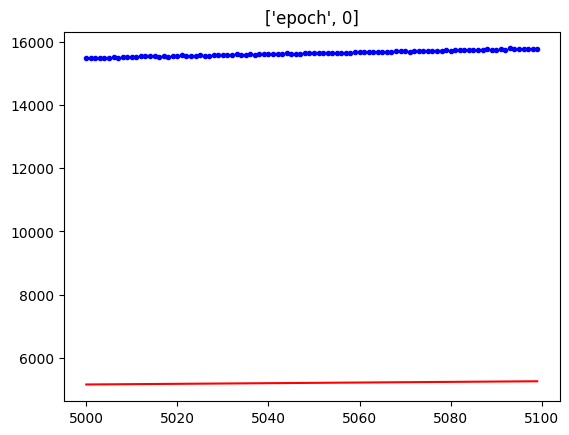

epoch is: 30, loss is 5245387.0,  W is: [[2.668393]], b is [1.0003465]


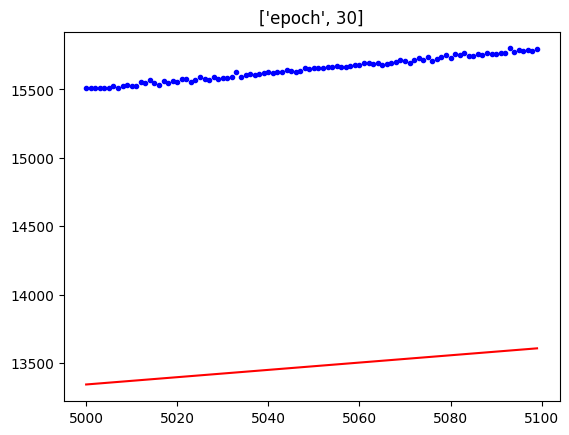

epoch is: 60, loss is 227004.078125,  W is: [[3.0092952]], b is [1.0004141]


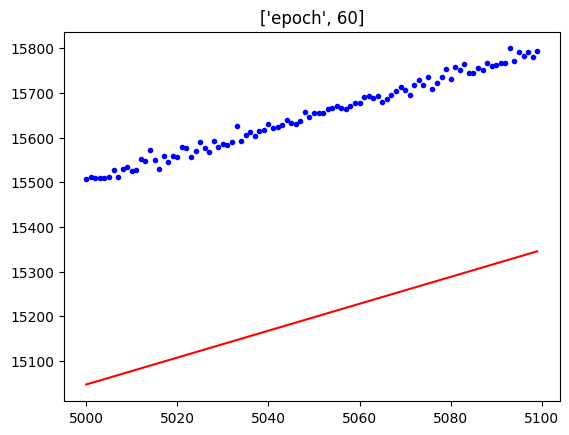

epoch is: 90, loss is 9919.5888671875,  W is: [[3.080198]], b is [1.0004282]


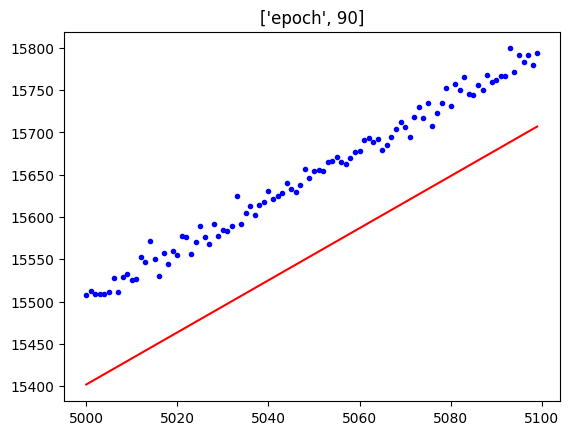

epoch is: 120, loss is 528.9721069335938,  W is: [[3.0949447]], b is [1.000431]


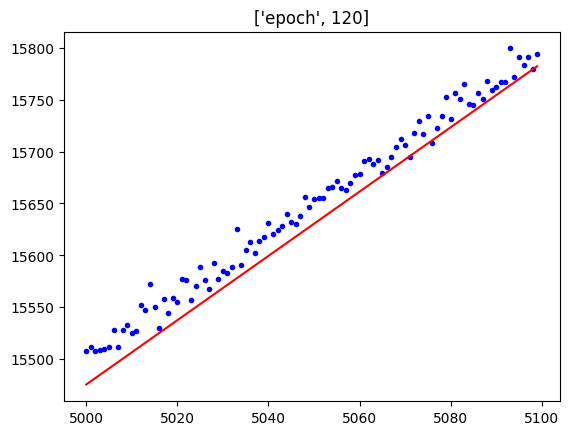

epoch is: 150, loss is 122.75215911865234,  W is: [[3.098012]], b is [1.000431]


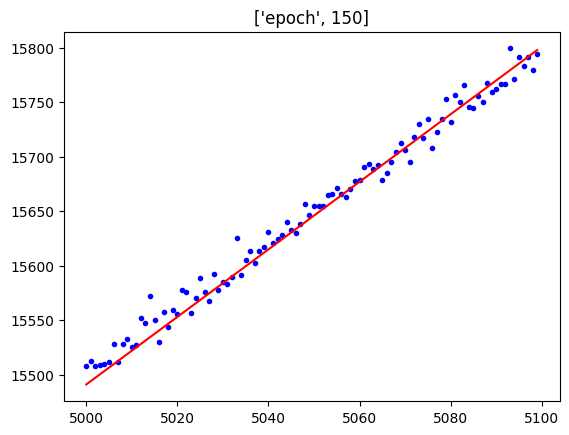

epoch is: 180, loss is 105.18037414550781,  W is: [[3.09865]], b is [1.000431]


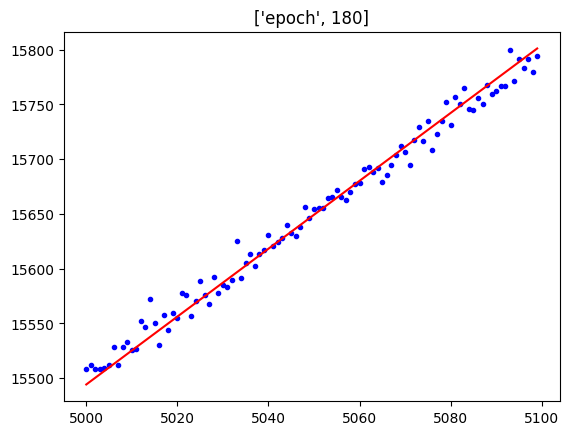

In [11]:
#Initialize Weights
W = tf.Variable(tf.random.uniform(shape=(1, 1)))
b = tf.Variable(tf.ones(shape=(1,)))

#Optimization
## Writing training/learing loop with GradienTape
learning_rate = 0.000000001
steps = 200 #epochs

for i in range(steps):
    with tf.GradientTape() as tape:
        predictions = output(x_train)
        loss = loss_function(predictions,y_train)
        dloss_dw, dloss_db = tape.gradient(loss, [W, b])
    W.assign_sub(learning_rate * dloss_dw)
    b.assign_sub(learning_rate * dloss_db)
    if i%30 == 0:
        print(f"epoch is: {i}, loss is {loss.numpy()},  W is: {W.numpy()}, b is {b.numpy()}")
        plt.title(["epoch", i])
        plt.plot(x_train, y_train, 'b.')
        plt.plot(x_train, output(x_train), c='r')
        plt.show()

### Logistic Regression Model building in TensorFlow

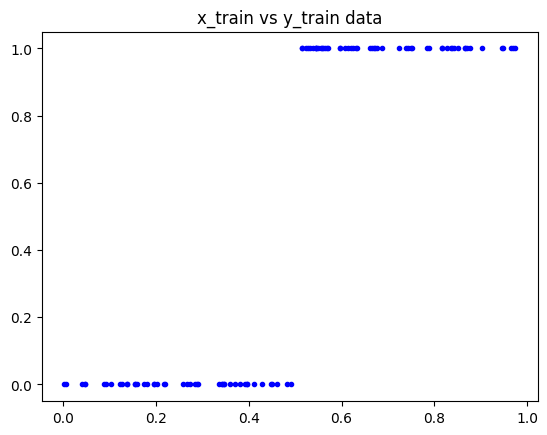

In [12]:
# This step is for data creation
x_train= np.random.rand(100,1)
y_train=np.array([0 if i < 0.5 else 1 for i in x_train]).reshape(-1,1)

import matplotlib.pyplot as plt
plt.title("x_train vs y_train data")
plt.plot(x_train, y_train, 'b.',)
plt.show()

In [13]:
#Model y=sigmoid(X*W + b)
# same as the linear regression just sigmoid wrapped around the linear equation
def output(x): 
    return tf.sigmoid(W*x + b)

#Loss function : sum of squares
def loss_function(y_pred, y_true):
    return tf.reduce_sum(tf.square(y_pred - y_true))

#Initialize Weights
W = tf.Variable(tf.random.uniform(shape=(1, 1)))
b = tf.Variable(tf.zeros(shape=(1,)))

## Optimization
learning_rate = 0.1
steps = 300 #epochs

for i in range(steps):
    with tf.GradientTape() as tape:
        predictions = output(x_train)
        loss = loss_function(y_train, predictions)
        dloss_dw, dloss_db = tape.gradient(loss, [W, b])
    W.assign_sub(learning_rate * dloss_dw)
    b.assign_sub(learning_rate * dloss_db)
    print(f"epoch : {i}, loss  {loss.numpy()},  W : {W.numpy()}, b  {b.numpy()}")

epoch : 0, loss  20.921878814697266,  W : [[1.1427944]], b  [-0.38995877]
epoch : 1, loss  19.1137752532959,  W : [[1.5597776]], b  [-0.444494]
epoch : 2, loss  17.60295867919922,  W : [[1.8265047]], b  [-0.71484405]
epoch : 3, loss  16.329320907592773,  W : [[2.1625433]], b  [-0.7907075]
epoch : 4, loss  15.252870559692383,  W : [[2.4061553]], b  [-0.9894425]
epoch : 5, loss  14.338052749633789,  W : [[2.6813855]], b  [-1.0754169]
epoch : 6, loss  13.555137634277344,  W : [[2.902363]], b  [-1.2237525]
epoch : 7, loss  12.88003158569336,  W : [[3.13234]], b  [-1.3141401]
epoch : 8, loss  12.292976379394531,  W : [[3.3325076]], b  [-1.4288944]
epoch : 9, loss  11.77840805053711,  W : [[3.5299628]], b  [-1.5176307]
epoch : 10, loss  11.323835372924805,  W : [[3.7108924]], b  [-1.6117779]
epoch : 11, loss  10.919391632080078,  W : [[3.8849652]], b  [-1.694788]
epoch : 12, loss  10.557149887084961,  W : [[4.0487223]], b  [-1.776323]
epoch : 13, loss  10.23073673248291,  W : [[4.205256]], b

Plotting

epoch is: 0, loss is 20.862560272216797,  W is: [[1.155391]], b is [-0.40466633]


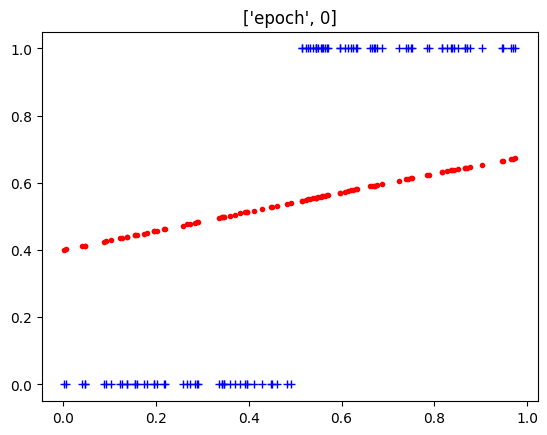

epoch is: 40, loss is 6.5185017585754395,  W is: [[6.920101]], b is [-3.1702673]


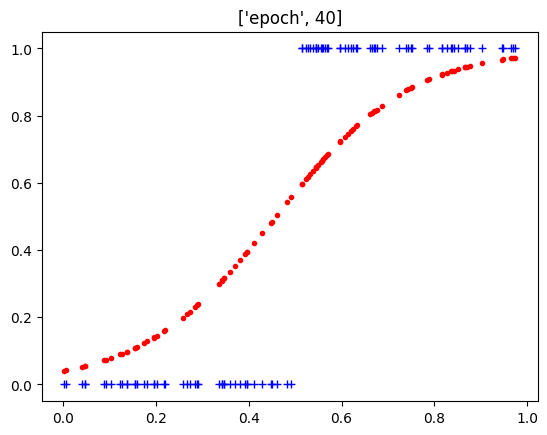

epoch is: 80, loss is 4.9669389724731445,  W is: [[9.117735]], b is [-4.238668]


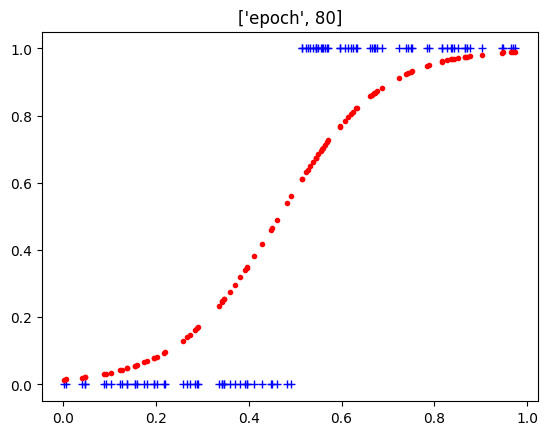

epoch is: 120, loss is 4.238139629364014,  W is: [[10.638695]], b is [-4.9820695]


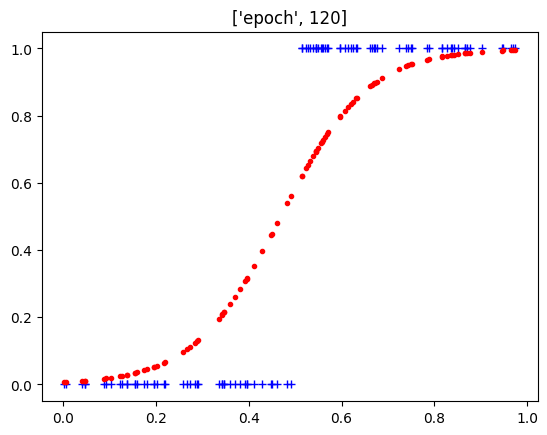

epoch is: 160, loss is 3.7838048934936523,  W is: [[11.842583]], b is [-5.5726633]


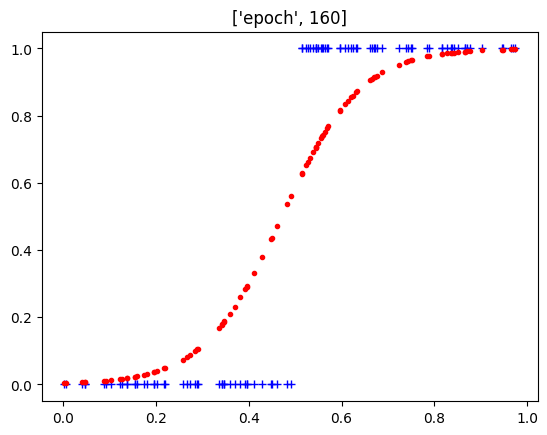

epoch is: 200, loss is 3.4629836082458496,  W is: [[12.855184]], b is [-6.070782]


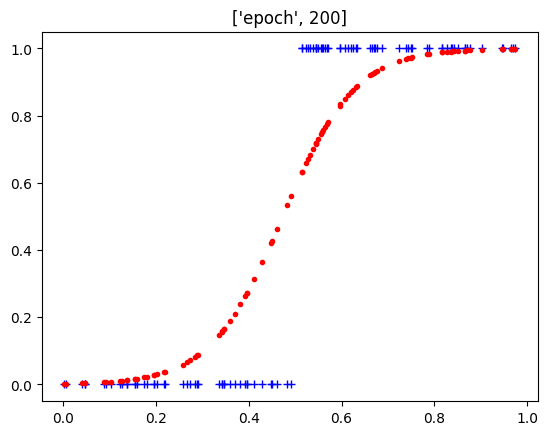

epoch is: 240, loss is 3.2197723388671875,  W is: [[13.737194]], b is [-6.5056267]


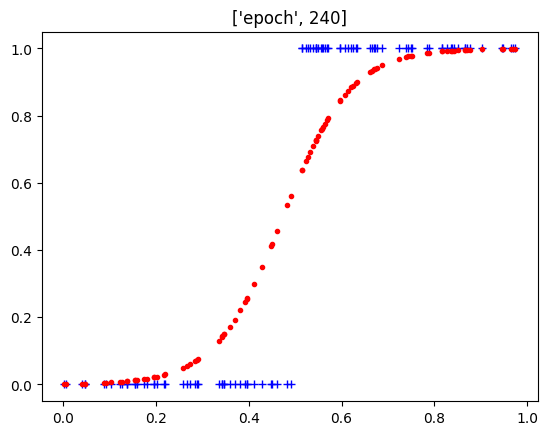

epoch is: 280, loss is 3.026671886444092,  W is: [[14.523238]], b is [-6.893893]


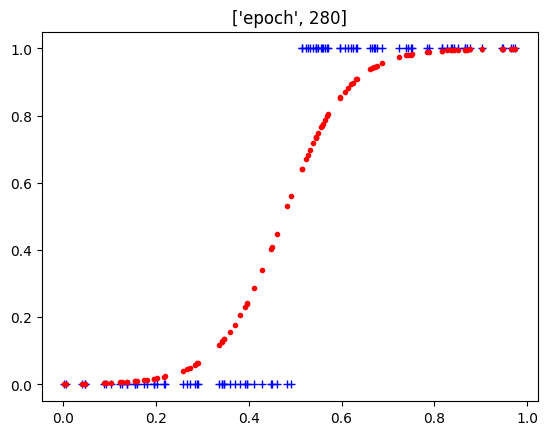

In [14]:
#Model y=X*W + b
# same as the linear regression just sigmoid wrapped around the linear equation
def output(x): 
    return tf.sigmoid(W*x + b)

#Loss function : sum of squares
def loss_function(y_pred, y_true):
    return tf.reduce_sum(tf.square(y_pred - y_true))

#Initialize Weights
W = tf.Variable(tf.random.uniform(shape=(1, 1)))
b = tf.Variable(tf.zeros(shape=(1,)))

## Optimization
learning_rate = 0.1
steps = 300 #epochs

for i in range(steps):
    with tf.GradientTape() as tape:
        predictions = output(x_train)
        loss = loss_function(y_train, predictions)
        dloss_dw, dloss_db = tape.gradient(loss, [W, b])
    W.assign_sub(learning_rate * dloss_dw)
    b.assign_sub(learning_rate * dloss_db)

    if i%40 == 0:
        print(f"epoch is: {i}, loss is {loss.numpy()},  W is: {W.numpy()}, b is {b.numpy()}")
        plt.title(["epoch", i])
        plt.plot(x_train, y_train, 'b+')
        plt.plot(x_train, output(x_train), '.', c='r')
        plt.show()

# Keras

In [15]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [16]:
## The data, shuffled and split between train and test sets
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()
num_classes=10
x_train = X_train.reshape(60000, 784)
x_test = X_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

## Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(Y_train, num_classes)
y_test = keras.utils.to_categorical(Y_test, num_classes)

print(x_train.shape, 'train input samples')
print(x_test.shape, 'test input samples')

print(y_train.shape, 'train output samples')
print(y_test.shape, 'test output samples')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
(60000, 784) train input samples
(10000, 784) test input samples
(60000, 10) train output samples
(10000, 10) test output samples


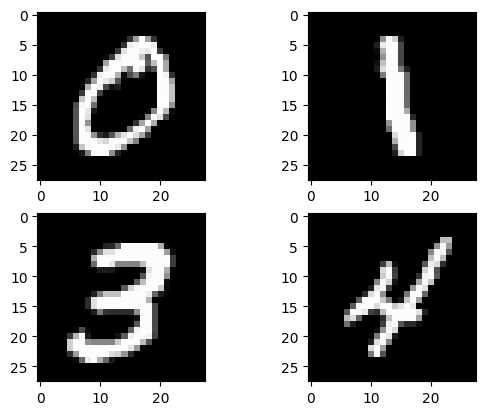

In [17]:
# Plot 4 images as gray scale

%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot(221)
plt.imshow(X_train[1], cmap=plt.get_cmap('gray'))
plt.subplot(222)
plt.imshow(X_train[6], cmap=plt.get_cmap('gray'))
plt.subplot(223)
plt.imshow(X_train[7], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(X_train[9], cmap=plt.get_cmap('gray'))

# show the plot
plt.show()

In [18]:
model = keras.Sequential()
model.add(layers.Input(shape=(784,)))
#Input Layer. The model needs to know what input shape it should expect. 
#For this reason, the first layer in a Sequential model needs to receive information about its input shape.
#Only the first need the snape information, because following layers can do automatic shape inference
model.add(layers.Dense(20, activation='sigmoid')) #, input_shape=(784,)))

#The dense layer is simply a layer where each unit or neuron is connected to each neuron in the next layer.
model.add(layers.Dense(20, activation='sigmoid'))

#In the final layer mention the output classes
model.add(layers.Dense(10, activation='softmax'))

#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,330 (63.79 KB)

 Trainable params: 16,330 (63.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compiling model : we define loss function, optimizer and validation matric of our choice
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

# Fit method: actually running our model by supplying our input and validation data
model.fit(x_train, y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6158 - loss: 1.5031
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9011 - loss: 0.3665
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9251 - loss: 0.2652
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9365 - loss: 0.2192
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9443 - loss: 0.1950
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9468 - loss: 0.1774
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9515 - loss: 0.1627
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9554 - loss: 0.1516
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9566 - loss: 0.1457
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9608 - loss: 0.1329


In [20]:
print(model.get_weights())

[array([[ 0.04625024,  0.04988839, -0.05721589, ..., -0.06074314,
        -0.08233824, -0.05724701],
       [-0.00215896, -0.03825442,  0.05489773, ...,  0.06109753,
         0.03426024,  0.06820774],
       [-0.02856034, -0.02360089,  0.05299589, ...,  0.0765864 ,
        -0.07335652, -0.04552747],
       ...,
       [-0.0808652 , -0.00031283,  0.07815267, ..., -0.04340863,
        -0.0041653 ,  0.05261725],
       [-0.02395094, -0.02769062,  0.02025332, ...,  0.02117342,
        -0.04764608, -0.06205666],
       [ 0.0333634 , -0.05339568, -0.06896493, ...,  0.08222589,
         0.03894567,  0.08352365]], dtype=float32), array([-0.6230561 ,  0.02083313, -0.22334625,  0.10856489, -0.2941903 ,
        0.20348728, -0.16884217, -0.05022225, -0.03522133,  0.06603644,
        0.1202321 , -0.14679836, -0.01065548,  0.08937633, -0.24159165,
        0.29222596,  0.40059444,  0.40988624, -0.62595797,  0.29925147],
      dtype=float32), array([[-0.6983733 ,  1.1296767 ,  0.8696168 , -1.0691934 ,

In [21]:
loss, acc = model.evaluate(x_test,  y_test, verbose=2)
print("Test Accuracy: {:5.2f}%".format(100*acc))

313/313 - 0s - 1ms/step - accuracy: 0.9516 - loss: 0.1545
Test Accuracy: 95.16%


In [4]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available and being used!")
else:
    print("GPU is NOT available.  Using CPU.")

# Example of running a simple computation on the GPU
with tf.device('/GPU:0'):  # Use the first GPU
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[5.0, 6.0], [7.0, 8.0]])
    c = tf.matmul(a, b)
    print("Result on GPU:", c)

GPU is NOT available.  Using CPU.
Result on GPU: tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)
